
# Taller de Imputación de Datos

Este notebook desarrolla el taller final de imputacion, usando la base `base_imputacion_mixta_1000.csv`.  
Se siguen las instrucciones: exploración de nulos, clasificación MCAR/MAR/MNAR (heurística), aplicación de métodos de imputación (mediana/moda, KNN, MICE, por grupo), y construcción de tabla resumen.

---


## Exploracion inicial

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")


# Cargar datos locales
url = "https://raw.githubusercontent.com/Kalbam/Datos/refs/heads/main/base_imputacion_mixta_1000.csv"
df = pd.read_csv(url)
df.head()


,fecha,sexo,ciudad,nivel_educativo,segmento,estado_civil,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
0,2024-01-01,F,Medellín,NaN,B,Unión libre,19.0,161.821754,3574.753806,1832.731832,640.465372,119.202995
1,2024-01-02,F,Barranquilla,NaN,B,NaN,52.0,167.819566,3163.626815,NaN,533.108430,124.457874
2,2024-01-03,M,Bogotá,Secundaria,B,Soltero/a,38.0,165.756219,2765.672259,1219.535074,491.016910,NaN
3,2024-01-04,F,Bogotá,NaN,B,Casado/a,57.0,160.642670,4320.397345,1908.324816,NaN,129.426792
4,2024-01-05,M,Cali,Técnico,B,Soltero/a,67.0,151.402909,NaN,1887.385697,610.213994,133.916319


In [22]:
df.drop("fecha", axis=1, inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sexo                980 non-null    object 
 1   ciudad              950 non-null    object 
 2   nivel_educativo     900 non-null    object 
 3   segmento            800 non-null    object 
 4   estado_civil        650 non-null    object 
 5   edad                970 non-null    float64
 6   altura_cm           920 non-null    float64
 7   ingresos            880 non-null    float64
 8   gasto_mensual       750 non-null    float64
 9   puntuacion_credito  500 non-null    float64
 10  demanda             850 non-null    float64
dtypes: float64(6), object(5)
memory usage: 86.1+ KB


In [23]:
df.describe()

,edad,altura_cm,ingresos,gasto_mensual,puntuacion_credito,demanda
count,970.000000,920.000000,880.000000,750.000000,500.000000,850.000000
mean,42.861856,167.760096,3681.294745,1687.810749,599.077500,160.305759
std,14.621382,9.275530,1079.326096,582.070174,79.828186,25.357794
min,18.000000,140.000000,487.662547,100.000000,373.657944,99.875828
25%,30.000000,161.488768,2999.416229,1309.239768,544.467843,139.505538
50%,43.000000,167.714614,3669.620507,1676.193764,599.692595,160.721251
75%,55.000000,173.999069,4375.093656,2063.260990,653.345068,181.100754
max,69.000000,195.766921,7016.246936,3532.593603,823.539585,222.093047


In [24]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Valores faltantes': missing_values,
    'Porcentaje (%)': missing_percent
})
print("Resumen de valores faltantes:\n", missing_df)

Resumen de valores faltantes:
                     Valores faltantes  Porcentaje (%)
sexo                               20             2.0
ciudad                             50             5.0
nivel_educativo                   100            10.0
segmento                          200            20.0
estado_civil                      350            35.0
edad                               30             3.0
altura_cm                          80             8.0
ingresos                          120            12.0
gasto_mensual                     250            25.0
puntuacion_credito                500            50.0
demanda                           150            15.0


## Deteccion valores faltantes

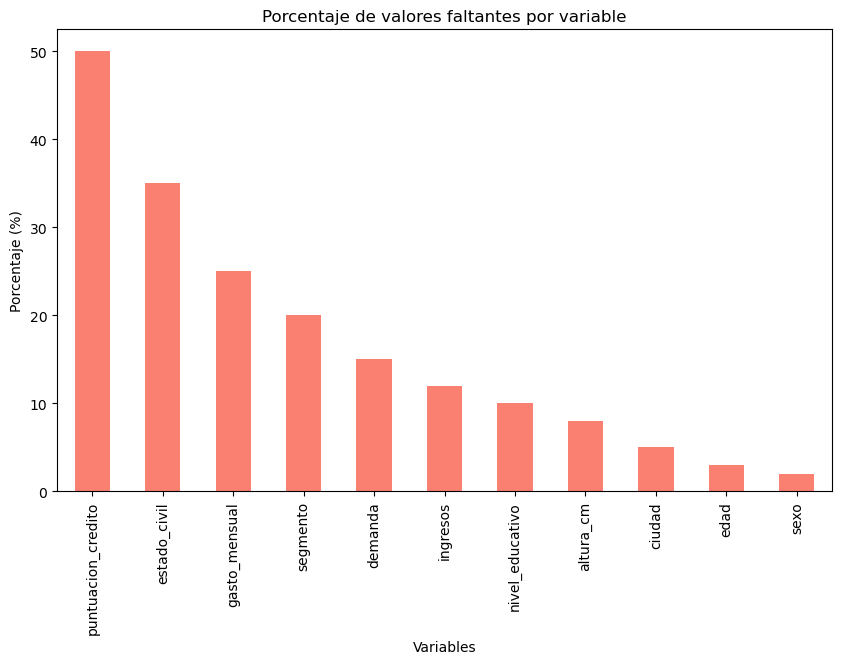

In [25]:
plt.figure(figsize=(10,6))
missing_percent.sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Porcentaje de valores faltantes por variable')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Variables')
plt.show()

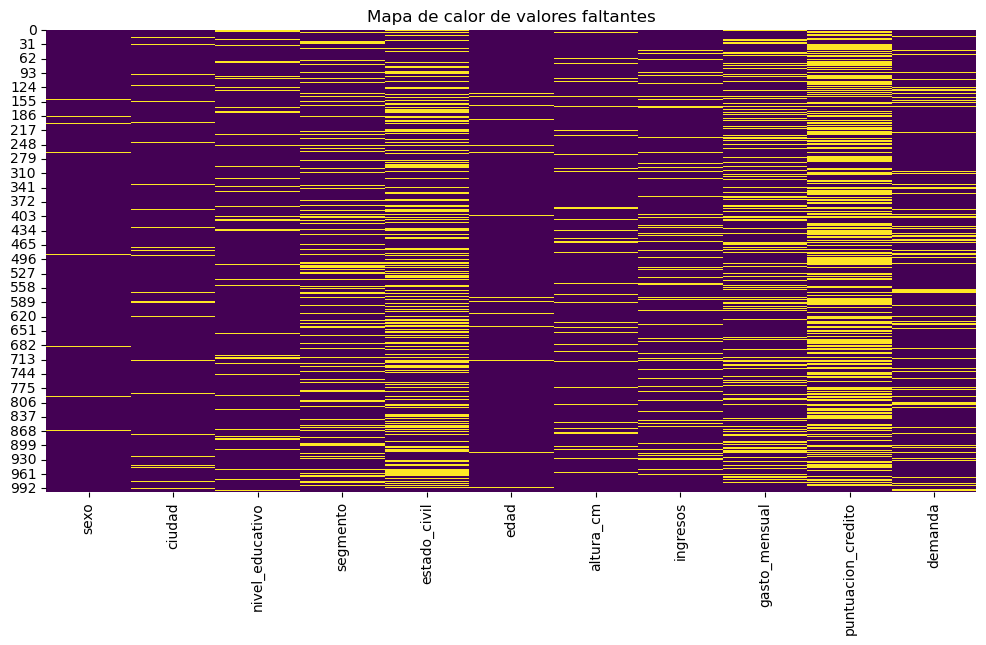

In [26]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title('Mapa de calor de valores faltantes')
plt.show()

## Clasificación preliminar

### Posibles MCAR (faltan al azar, sin relación con otras variables ni con su propio valor):

- sexo, edad, altura_cm: Pocos faltantes, sin patrón aparente en el mapa de calor. Probablemente errores aleatorios.

### Posibles MAR (faltan según otras variables observadas, pero no por el propio valor faltante):

- estado_civil, gasto_mensual, segmento, nivel_educativo, ciudad, demanda:
El mapa de calor muestra que cuando faltan, tienden a agruparse en ciertos registros, lo que sugiere relación con otras características (ej. ciertas ciudades o segmentos socioeconómicos podrían registrar menos datos).

- ingresos: Suele correlacionarse con nivel educativo y gasto, por lo que es plausible que su ausencia dependa de estas.

### Posibles MNAR (faltan por la naturaleza del propio valor):

- puntuacion_credito: Muy alto porcentaje de faltantes (~50%), y es posible que quienes tienen mal puntaje no lo reporten → sesgo propio del dato.


## Análisis de Imputabilidad por Variable

| Variable             | % Faltantes | ¿Imputar o dejar nulos?                            | Riesgo de imputar                                  | Técnica a considerar                                  |
|----------------------|-------------|----------------------------------------------------|--------------------------------------------------|----------------------------------------------------|
| **puntuacion_credito** | ~50%        | Eliminar columna                         | Alto: MNAR posible                                 | Mucho riesgo, tenemos que eliminar la columna  |
| **estado_civil**      | ~35%        | Eliminar                                            | Medio: puede sesgar perfiles                      | Presenta tambien un riesgo elevado, ademas de ser una variable dificil de imputar      |
| **gasto_mensual**     | ~25%        | Ignorar     | Medio: riesgo de distorsión en valores extremos    | **MICE** o **Regresión**                            |
| **segmento**          | ~20%        | Imputar                                            | Bajo: categórica                                   | **Hot-deck** o **KNN**                              |
| **demanda**           | ~15%        | Imputar si es clave                                 | Medio: posible MNAR (baja demanda no reportada)    | **Mice** o **KNN**                             |
| **ingresos**          | ~12%        | Imputar                                            | Medio: correlación con gasto_mensual               | **KNN** o **Mediana** si es bajo porcentaje         |
| **nivel_educativo**    | ~10%        | Imputar                                            | Bajo: categórica                                   | **Moda** o **Hot-deck**                             |
| **altura_cm**         | ~8%         | Imputar si es relevante                            | Bajo: Posible falta de valores extremos       | **Mediana** o **Regresión** si correlaciona          |
| **ciudad**            | ~5%         | Imputar si es necesaria para el análisis           | Bajo: categórica                                   | **Moda**                                            |
| **edad**              | ~3%         | Imputar                                            | Bajo: posible correlación con ingresos             | **Mediana** o **Regresión** si es predictor útil     |
| **sexo**              | ~2%         | Imputar                                            | Bajo: categórica                                   | **Moda**                                            |
                                       |


## Eliminacion de columnas que no vamos a imputar

In [27]:
df.drop("puntuacion_credito", axis=1, inplace=True)
df.drop("estado_civil", axis=1, inplace=True)
df.drop("gasto_mensual", axis=1, inplace=True)

### Test de normalidad antes de imputar

In [28]:
from scipy.stats import shapiro
# Test de Shapiro-Wilk para todas las variables numéricas
results = [(col, *shapiro(df[col].dropna())) for col in df.select_dtypes(include=[float, int]).columns]

# Convertir a DataFrame para ver los resultados ordenados
normalidad_df = pd.DataFrame(results, columns=["Variable", "Estadístico", "p-valor"])
display(normalidad_df)

,Variable,Estadístico,p-valor
0,edad,0.959825,1.132185e-15
1,altura_cm,0.998442,5.911472e-01
2,ingresos,0.997857,3.244752e-01
3,demanda,0.984921,1.129628e-07


### Imputaciones

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num_vars = df.select_dtypes(include=[np.number]).columns
cat_vars = df.select_dtypes(exclude=[np.number]).columns

# --- Crear una copia para imputación ---
df_imputed = df.copy()

# --- Imputación para variables numéricas ---
# Mediana para edad 
df_imputed["edad"].fillna(df_imputed["edad"].median(), inplace=True)

# MICE 
mice_vars = ["altura_cm"]
mice_imputer = IterativeImputer(max_iter=10, random_state=0)
df_imputed[mice_vars] = mice_imputer.fit_transform(df_imputed[mice_vars])

# KNN 
knn_vars = ["ingresos", "demanda"]
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed[knn_vars] = knn_imputer.fit_transform(df_imputed[knn_vars])

# --- Imputación para variables categóricas ---

# Hot deck 
df_imputed["nivel_educativo"] = df["nivel_educativo"].fillna(df["nivel_educativo"].dropna().sample(frac=1, replace=True).reset_index(drop=True))

# Moda para <10 %
df_imputed["ciudad"].fillna(df_imputed["ciudad"].mode()[0], inplace=True)
df_imputed["sexo"].fillna(df_imputed["sexo"].mode()[0], inplace=True)

# KNN (convertimos a códigos numéricos antes)
cat_knn_vars = ["segmento"]

for col in cat_knn_vars:
    # Guardamos categorías originales
    categorias_originales = df_imputed[col].astype('category').cat.categories
    
    # Convertimos a códigos numéricos (NaN para los -1)
    df_imputed[col] = df_imputed[col].astype('category').cat.codes.replace(-1, np.nan)

if cat_knn_vars:
    knn_imputer = KNNImputer(n_neighbors=5)
    df_imputed[cat_knn_vars] = knn_imputer.fit_transform(df_imputed[cat_knn_vars])

    # Redondeamos a enteros
    df_imputed[cat_knn_vars] = df_imputed[cat_knn_vars].round().astype("Int64")

    # Mapear de vuelta a categorías originales
    for col in cat_knn_vars:
        df_imputed[col] = df_imputed[col].map(dict(enumerate(categorias_originales)))

### Test de normalidad post-imputacion

In [30]:
results = [(col, *shapiro(df_imputed[col])) for col in df_imputed.select_dtypes(include=[float, int]).columns]

# Convertir a DataFrame para ver los resultados ordenados
normalidad_df = pd.DataFrame(results, columns=["Variable", "Estadístico", "p-valor"])
display(normalidad_df)

,Variable,Estadístico,p-valor
0,edad,0.963456,3.925093e-15
1,altura_cm,0.995444,4.479207e-03
2,ingresos,0.995122,2.693730e-03
3,demanda,0.992913,1.045234e-04


# Generacion de graficos comparativos

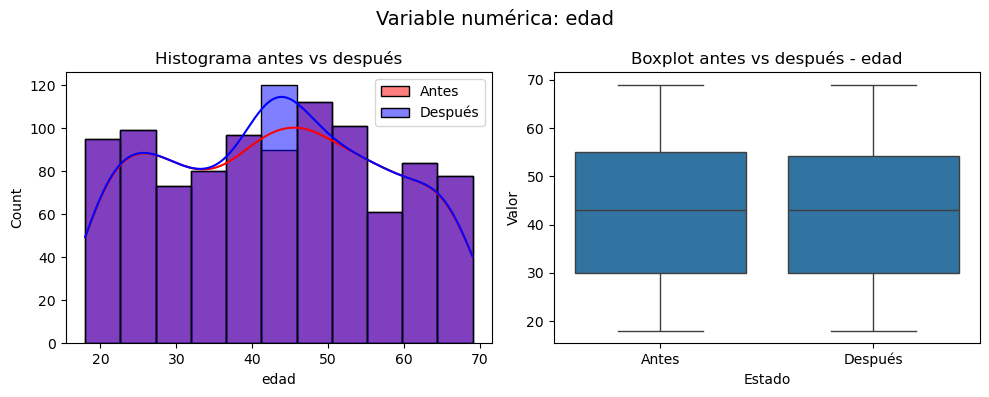

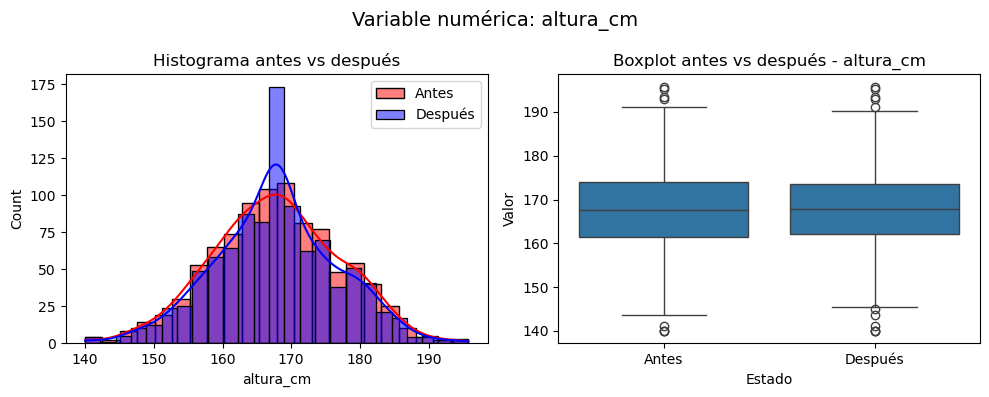

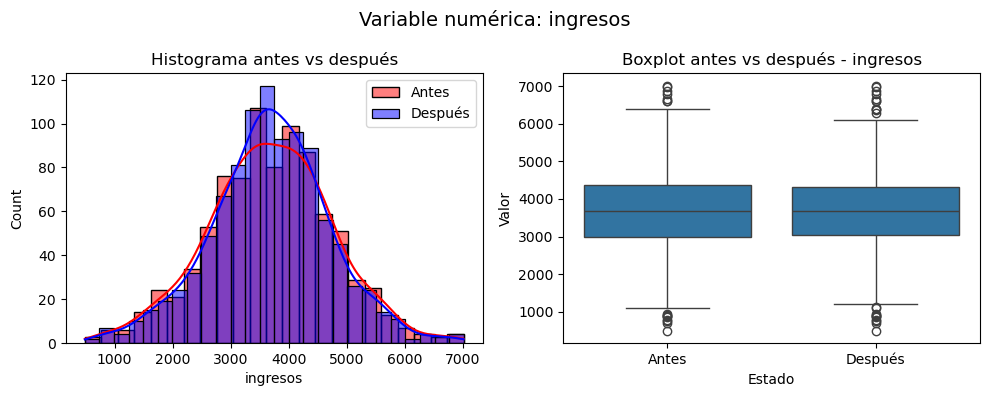

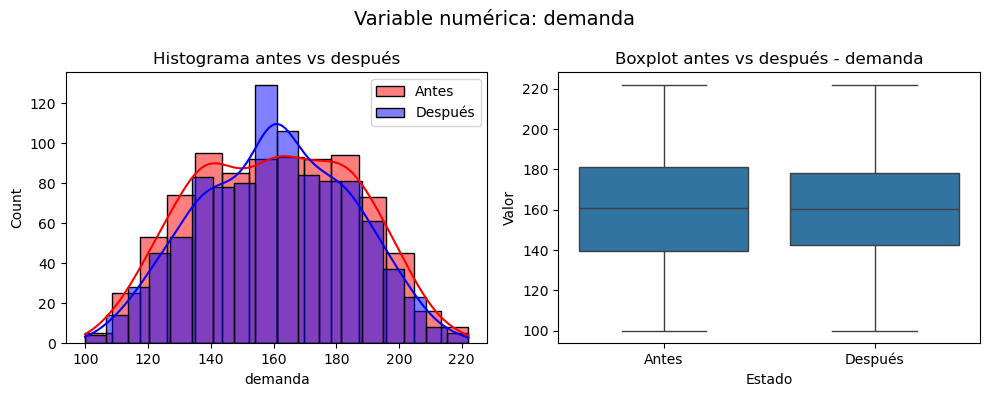

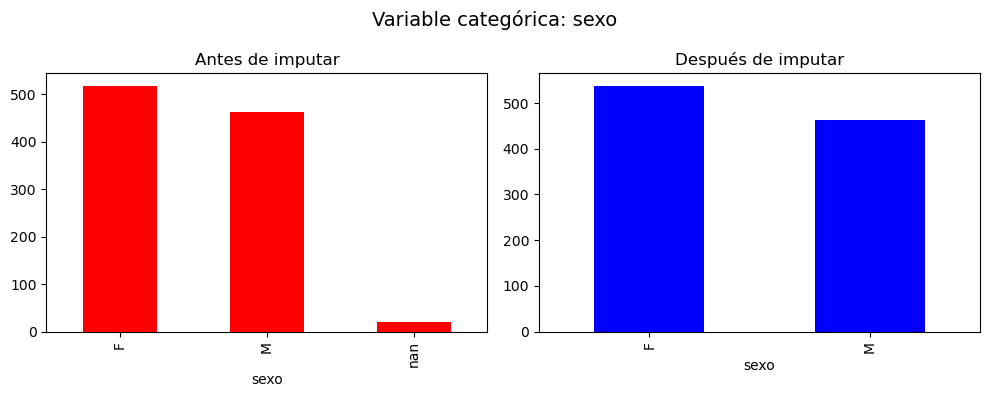

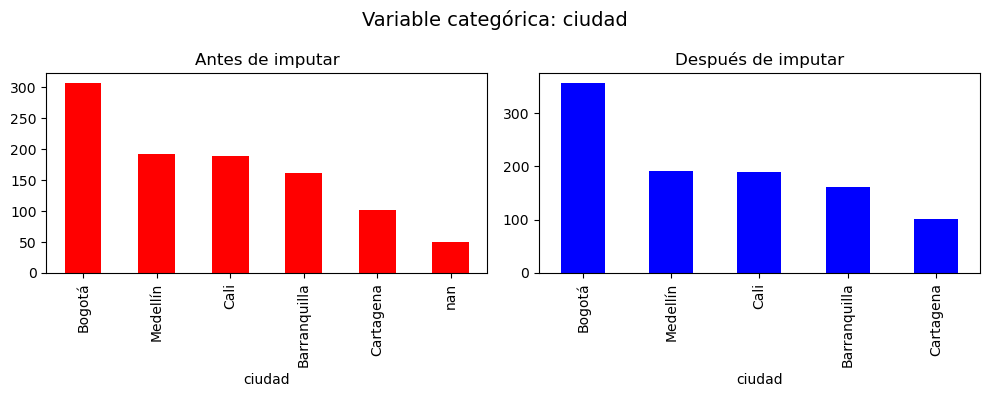

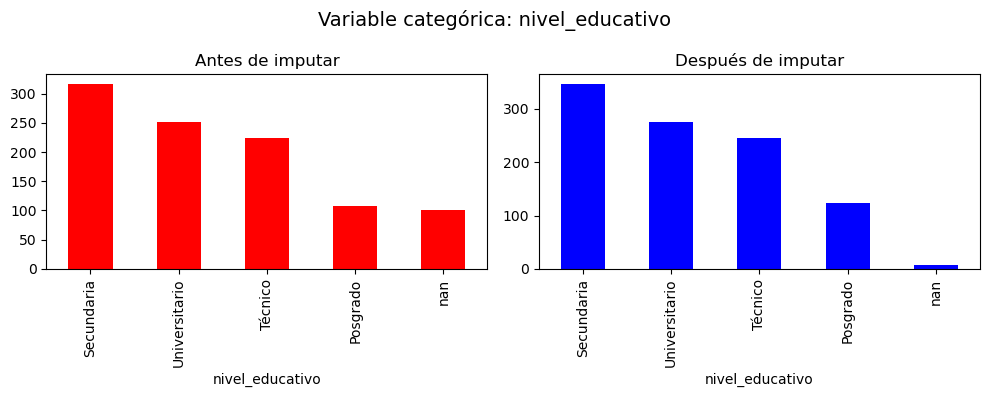

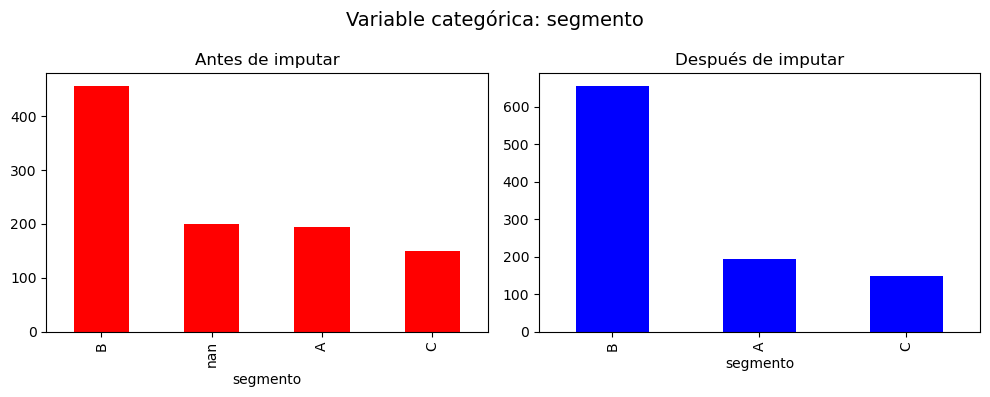

In [31]:
# --- 1) Gráficos para variables numéricas ---
for col in num_vars:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Variable numérica: {col}", fontsize=14)

    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[0], color="red", label="Antes")
    sns.histplot(df_imputed[col], kde=True, ax=axes[0], color="blue", label="Después")
    axes[0].legend()
    axes[0].set_title("Histograma antes vs después")
    
    #Boxplot
    df_long = pd.DataFrame({
        "Valor": pd.concat([df[col], df_imputed[col]], ignore_index=True),
        "Estado": ["Antes"] * len(df) + ["Después"] * len(df_imputed)
    })
    sns.boxplot(x="Estado", y="Valor", data=df_long, ax = axes[1])
    axes[1].set_title(f"Boxplot antes vs después - {col}")
    plt.tight_layout()
    plt.show()

# --- 2) Gráficos para variables categóricas ---
for col in cat_vars:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Variable categórica: {col}", fontsize=14)

    # Barras antes
    df[col].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="red")
    axes[0].set_title("Antes de imputar")

    # Barras después
    df_imputed[col].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color="blue")
    axes[1].set_title("Después de imputar")

    plt.tight_layout()
    plt.show()

# Evaluacion de las imputaciones

## Numericas

In [ ]:
from scipy.stats import ks_2samp, mannwhitneyu
import pandas as pd

# Crear lista para guardar resultados
resultados = []

# Recorremos todas las variables numéricas
for col in df.select_dtypes(include=[float, int]).columns:
    # Datos antes y después
    antes = df[col].dropna()
    despues = df_imputed[col].dropna()
    
    # Prueba KS para igualdad de distribuciones
    ks_stat, ks_p = ks_2samp(antes, despues)
    
    # Prueba Mann-Whitney U para medianas/rangos
    mw_stat, mw_p = mannwhitneyu(antes, despues, alternative='two-sided')
    
    resultados.append([col, ks_stat, ks_p, mw_stat, mw_p])

# Convertir a DataFrame con resultados
evaluacion_df = pd.DataFrame(resultados, columns=["Variable", "KS_Stat", "KS_p", "MW_Stat", "MW_p"])

# Interpretación: p > 0.05 → no hay diferencia significativa
evaluacion_df["Distribucion"] = evaluacion_df["KS_p"].apply(lambda x: "Preserva" if x > 0.05 else "Distorsiona")
evaluacion_df["Mediana/Rangos"] = evaluacion_df["MW_p"].apply(lambda x: "Preserva" if x > 0.05 else "Distorsiona")

display(evaluacion_df)


,Variable,KS_Stat,KS_p,MW_Stat,MW_p,Distribucion,Mediana/Rangos
0,edad,0.014784,0.999847,485075.0,0.995290,Preserva,Preserva
1,altura_cm,0.040174,0.407949,459840.0,0.989513,Preserva,Preserva
2,ingresos,0.027636,0.854208,439103.0,0.939155,Preserva,Preserva
3,demanda,0.040471,0.425267,423021.0,0.862818,Preserva,Preserva


## Categoricas

In [33]:
from scipy.stats import chi2_contingency

# Lista para guardar resultados
resultados_cat = []

# Filtrar variables categóricas
categoricas = df.select_dtypes(include=["object", "category"]).columns

for col in categoricas:
    # Frecuencia original
    freq_original = df[col].value_counts()

    # Frecuencia después de imputación
    freq_imputado = df_imputed[col].value_counts()

    # Asegurar que ambos tengan las mismas categorías
    categorias_completas = set(freq_original.index).union(set(freq_imputado.index))
    freq_original = freq_original.reindex(categorias_completas, fill_value=0)
    freq_imputado = freq_imputado.reindex(categorias_completas, fill_value=0)

    # Construir tabla de contingencia (2 filas: original e imputado)
    tabla = pd.DataFrame([freq_original, freq_imputado])

    # Prueba Chi-cuadrado
    chi2, p_val, dof, expected = chi2_contingency(tabla)

    resultados_cat.append([col, chi2, p_val])

# Convertir a DataFrame
categoricas_eval = pd.DataFrame(resultados_cat, columns=["Variable", "Chi2_Stat", "Chi2_p"])

# Interpretación: p > 0.05 => no hay diferencia significativa
categoricas_eval["Conclusion"] = categoricas_eval["Chi2_p"].apply(lambda x: "Preserva" if x > 0.05 else "Distorsiona")

display(categoricas_eval)

,Variable,Chi2_Stat,Chi2_p,Conclusion
0,sexo,0.140932,0.707356,Preserva
1,ciudad,2.484643,0.647388,Preserva
2,nivel_educativo,0.111818,0.990382,Preserva
3,segmento,13.855476,0.000980,Distorsiona


In [35]:

# --- Variables, % Nulos y Tipo Ausencia basado en análisis previo ---
datos = [
    ("segmento", "Categórica", 20, "MAR", "KNN", "Distorsiona", "N/A", "Distorsiona"),
    ("demanda", "Numérica", 15, "MAR", "KNN", "Preserva", "Preserva", "Preserva"),
    ("ingresos", "Numérica", 12, "MAR", "KNN", "Preserva", "Preserva", "Preserva"),
    ("nivel_educativo", "Categórica", 10, "MAR", "Hot-deck", "Preserva", "N/A", "Preserva"),
    ("altura_cm", "Numérica", 8, "MCAR", "Mice", "Preserva", "Preserva", "Preserva"),
    ("ciudad", "Categórica", 5, "MAR", "Moda", "Preserva", "N/A", "Preserva"),
    ("edad", "Numérica", 3, "MCAR", "Mediana", "Preserva", "Preserva", "Preserva"),
    ("sexo", "Categórica", 2, "MCAR", "Moda", "Preserva", "N/A", "Preserva"),
]

# Crear DataFrame
tabla = pd.DataFrame(datos, columns=["Variable", "Tipo", "% Nulos", "Tipo Ausencia", "Método imputación", "Distribución", "Mediana/Rangos", "Conclusión"])

# Convertir a Markdown para pegar en Jupyter Notebook
markdown_table = tabla.to_markdown(index=False)
print(markdown_table)

| Variable        | Tipo       |   % Nulos | Tipo Ausencia   | Método imputación   | Distribución   | Mediana/Rangos   | Conclusión   |
|:----------------|:-----------|----------:|:----------------|:--------------------|:---------------|:-----------------|:-------------|
| segmento        | Categórica |        20 | MAR             | KNN                 | Distorsiona    | N/A              | Distorsiona  |
| demanda         | Numérica   |        15 | MAR             | KNN                 | Preserva       | Preserva         | Preserva     |
| ingresos        | Numérica   |        12 | MAR             | KNN                 | Preserva       | Preserva         | Preserva     |
| nivel_educativo | Categórica |        10 | MAR             | Hot-deck            | Preserva       | N/A              | Preserva     |
| altura_cm       | Numérica   |         8 | MCAR            | Mice                | Preserva       | Preserva         | Preserva     |
| ciudad          | Categórica |         5 | MAR